# Plot D2.5/D3 analysis

In [28]:
here::i_am("thesis/D45_analysis_plotting.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))
library(Seurat)
library(dplyr)

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [2]:
args = list()
args$MOFA_factors = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')

args$indir = file.path(io$basedir, 'results/rna_atac/clustering/')
args$metadata = file.path(args$indir, 'metadata_mofa_clusters.txt.gz')

args$outdir = file.path(io$basedir, 'thesis/D25_3')
dir.create(args$outdir, showWarnings = F, recursive = T)

In [3]:
meta = fread(args$metadata)
early_meta = fread(file.path(args$indir, 'early_celltypes.txt.gz'))

In [4]:
meta = merge(meta, early_meta, by = 'cell')

In [5]:
# load sce
rna.sce <- load_SingleCellExperiment(io$rna.sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

Loading required package: scuttle



In [6]:
set.seed(1234)

In [7]:
options(repr.plot.width=20, repr.plot.height=5)

In [8]:
factors = fread(args$MOFA_factors)[match(meta$cell, cell)]

In [9]:
umap = uwot::umap(factors[,-1], n_neighbors = 25, min_dist = 0.2)

In [10]:
umap = as.data.table(umap) %>%
    setnames(c('umap1', 'umap2'))

In [11]:
summary(colnames(seurat) == factors$cell)

   Mode    TRUE 
logical   34628 

In [12]:
# Prepare mofa umap
factors.mtx = factors %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()
seurat[["mofa"]] <- CreateDimReducObject(embeddings = factors.mtx, key = "mofa_", assay = DefaultAssay(seurat))

In [13]:
umap.mtx = umap %>% 
    .[,cell := meta[day != 'D4.5', cell]] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

seurat[["umap"]] <- CreateDimReducObject(embeddings = umap.mtx, key = "umap_", assay = DefaultAssay(seurat))

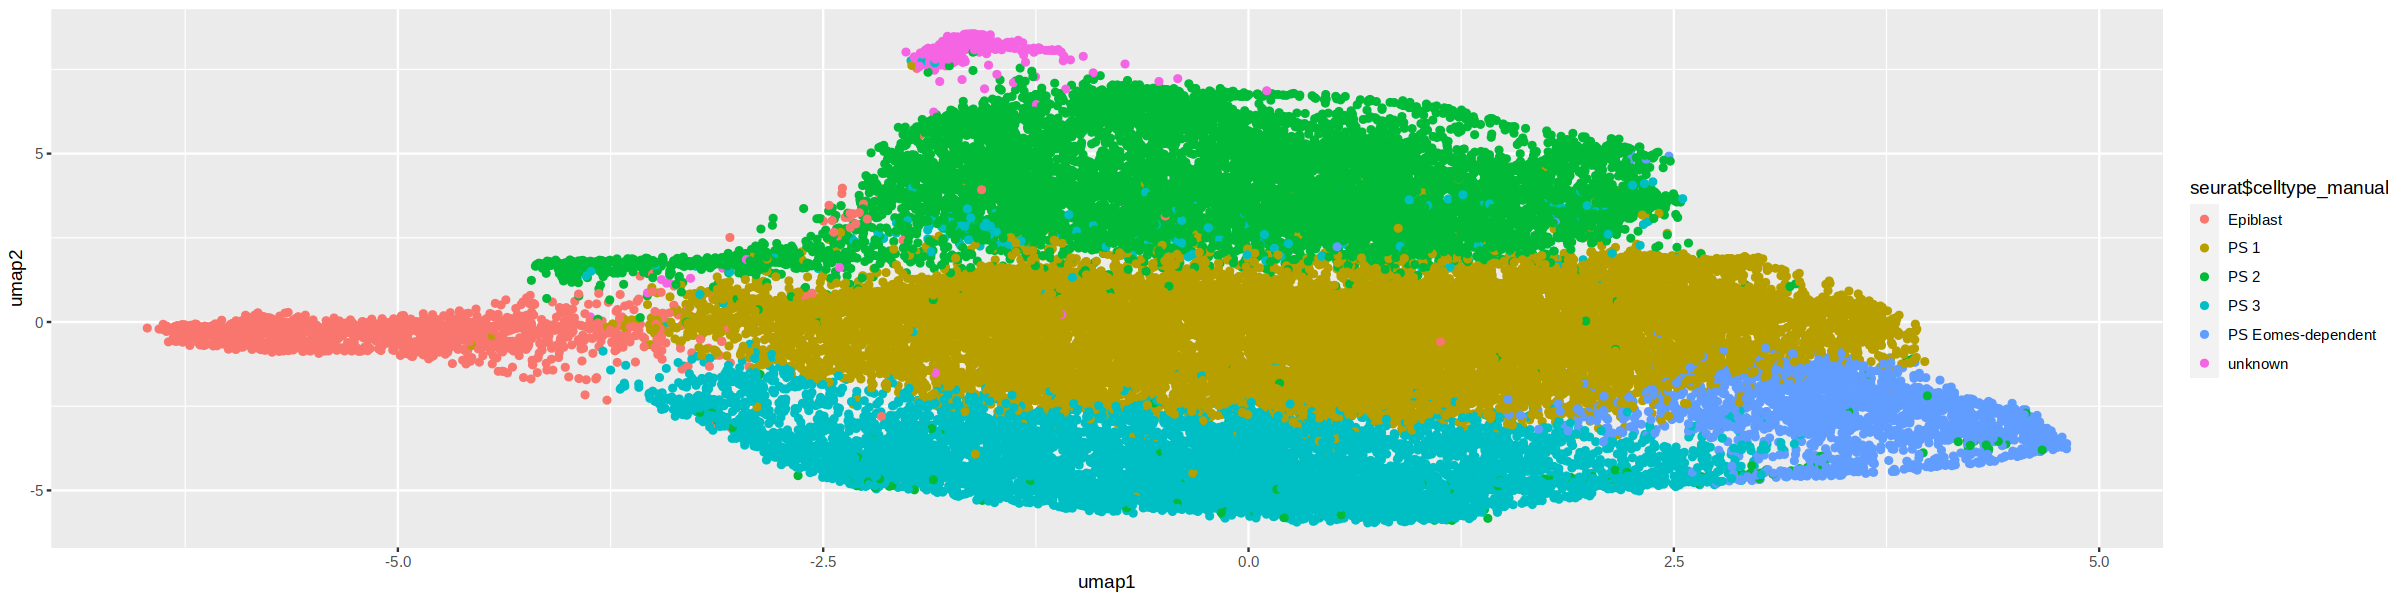

In [14]:
ggplot(umap, aes(umap1, umap2, color = seurat$celltype_manual)) + geom_point()

In [15]:
meta = merge(meta, umap, by = 'cell') %>%
    .[,genotype := gsub('_KO', ' KD', genotype)] 

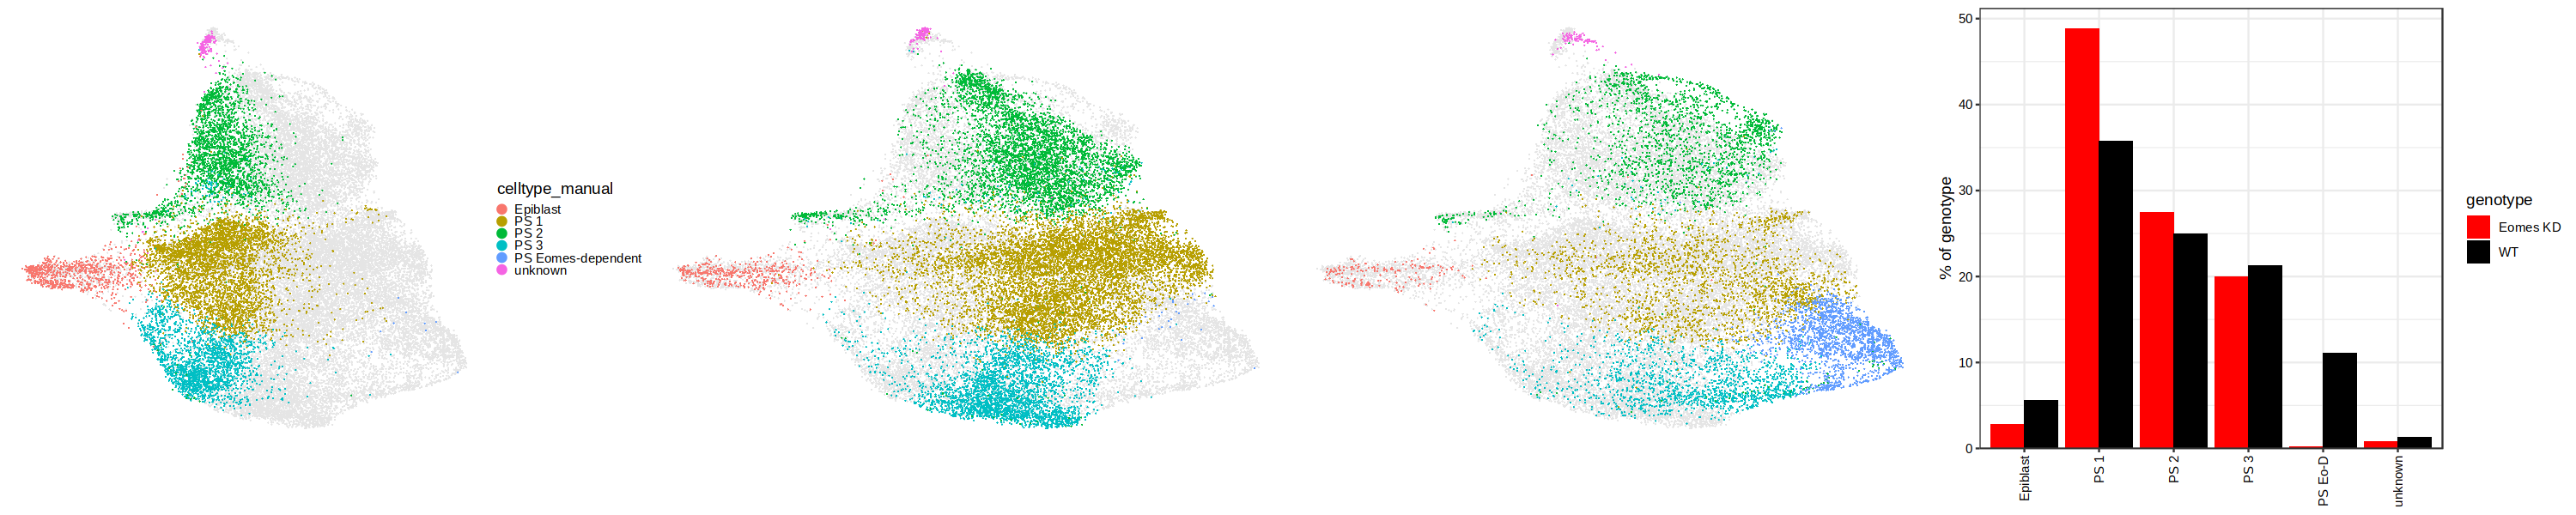

In [23]:
p1 = ggplot(meta[day == 'D2.5'], aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(data = meta[day == 'D3'], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) +     guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void() + 
    theme(legend.key.size = unit(1.2, "mm"))

p2 = ggplot(copy(meta)[genotype == 'Eomes KD' & day == 'D3'], aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(data = meta[genotype == 'WT'], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void() + theme(legend.position = 'none')

p3 = ggplot(copy(meta)[genotype == 'WT' & day == 'D3'], aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(data = meta[genotype == 'Eomes KD' | genotype == 'WT' & day == 'D2.5'], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void()  + theme(legend.position = 'none')

meta_props = meta %>% copy() %>%
    .[, tot := .N, by = 'genotype'] %>%
    .[, prop := .N/tot, by = c('celltype_manual', 'genotype')] %>%
    .[, celltype_manual := gsub('Eomes-dependent', 'Eo-D', celltype_manual)]

p4 = ggplot(meta_props, aes(celltype_manual, prop * 100, fill = genotype)) +
    geom_bar(position = 'dodge', stat = 'identity') + 
    scale_fill_manual(values = c('Eomes KD' = 'red', 'WT' = 'black')) +
    scale_y_continuous(expand = c(0,0,0.05,0)) + 
    scale_x_discrete(limits = c(
                                'Epiblast', 
                                paste0('PS ', 1:3),
                                'PS Eo-D',
                                'unknown'
                                )) + 
    ylab('% of genotype') + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          axis.title.x = element_blank())

options(repr.plot.width = 25)
ggarrange(p1, p2, p3, p4, ncol = 4, align = 'h')
                      
# p4

In [24]:
ggsave(file.path(args$outdir, 'Early_UMAPs_proportions.pdf'), 
       plot = ggarrange(cowplot::ggdraw(get_legend(p1)), p1 + theme(legend.position = 'none'), p3, p2, p4, ncol = 5, widths = c(0.4, 0.8, 0.8, 0.8, 1)),
       width = 300, 
       height = 60, 
       units = "mm")

In [25]:
Idents(seurat) = seurat$celltype_manual

In [26]:
markers <- FindAllMarkers(seurat, only.pos = TRUE)

Calculating cluster PS 3

Calculating cluster PS 2

Calculating cluster PS 1

Calculating cluster Epiblast

Calculating cluster unknown

Calculating cluster PS Eomes-dependent



In [101]:
head(markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Sema3e,0,1.1254647,0.688,0.165,0,Ectoderm-like,Sema3e
Slc2a3,0,1.0625779,0.863,0.303,0,Ectoderm-like,Slc2a3
Slc2a1,0,1.0181860,0.920,0.542,0,Ectoderm-like,Slc2a1
Xkr4,0,0.9888577,0.725,0.218,0,Ectoderm-like,Xkr4
Nrxn1,0,0.8089563,0.445,0.072,0,Ectoderm-like,Nrxn1
Frem2,0,0.7919927,0.782,0.287,0,Ectoderm-like,Frem2


In [104]:
markers %>%
    group_by(cluster) %>%
    # dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 30) %>%
    ungroup() -> top30

In [ ]:
options(repr.plot.width=30, repr.plot.height=5)

DotPlot(object = seurat, features = top30$gene) + 
    NoLegend() + 
    scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0))

In [29]:
factors = fread(args$MOFA_factors)[cell %in% meta[day == 'D3', cell]]
factors.mtx = factors %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

In [34]:
meta = meta[day == 'D3'] %>%
    .[,genotype := gsub(' KD', '_KO', genotype)] 

meta = meta[!celltype_manual %in% c('Epiblast', 'unknown')]
factors.mtx = factors.mtx[meta$cell,]

In [40]:
neighbors = BiocNeighbors::findKNN(factors.mtx, 100, BPPARAM = BPPARAM)

In [41]:
day_props = meta %>% copy() %>%
    .[,Ntot := .N, by = c('day', 'genotype')] %>% 
    .[,c('day', 'genotype', 'Ntot')] %>% 
    dcast(day~genotype, value.var = 'Ntot') %>% 
    .[,ratio := Eomes_KO/(Eomes_KO+WT)]

id_gt = meta %>% copy() %>% 
    .[,c('genotype', 'day')] %>% 
    .[,cell:=.I]

 
DA = mclapply(1:nrow(meta), function(x){ # nrow(meta)
    print(x)
    tmp = data.table(cell = as.vector(neighbors$index[x,])) %>% 
        merge(., id_gt, by = 'cell')
    
    tmp1 = tmp %>% copy() %>% .[,N := .N, by = 'day'] %>% unique(by = 'day') %>% 
        merge(., day_props[,c('day', 'ratio')], by = 'day') %>% 
        .[, N_ratio := ratio * N]
    
    global_ratio = sum(tmp1$N_ratio)/sum(tmp1$N)

    pvalue = binom.test(nrow(tmp[genotype == 'Eomes_KO']), nrow(tmp), p = global_ratio,
           alternative = "two.sided",
           conf.level = 0.95)$p.value

    tmp2 = data.table(cell = x,
                      ratio = nrow(tmp[genotype == 'Eomes_KO']) / (nrow(tmp[genotype == 'Eomes_KO']) + nrow(tmp[genotype == 'WT'])),
                      global_ratio = global_ratio,
                      pvalue = pvalue)
}, mc.cores = 16) %>% rbindlist() %>%
    .[,cell := meta$cell]

Aggregate function missing, defaulting to 'length'



In [42]:
meta3 = merge(meta, DA, by = 'cell')

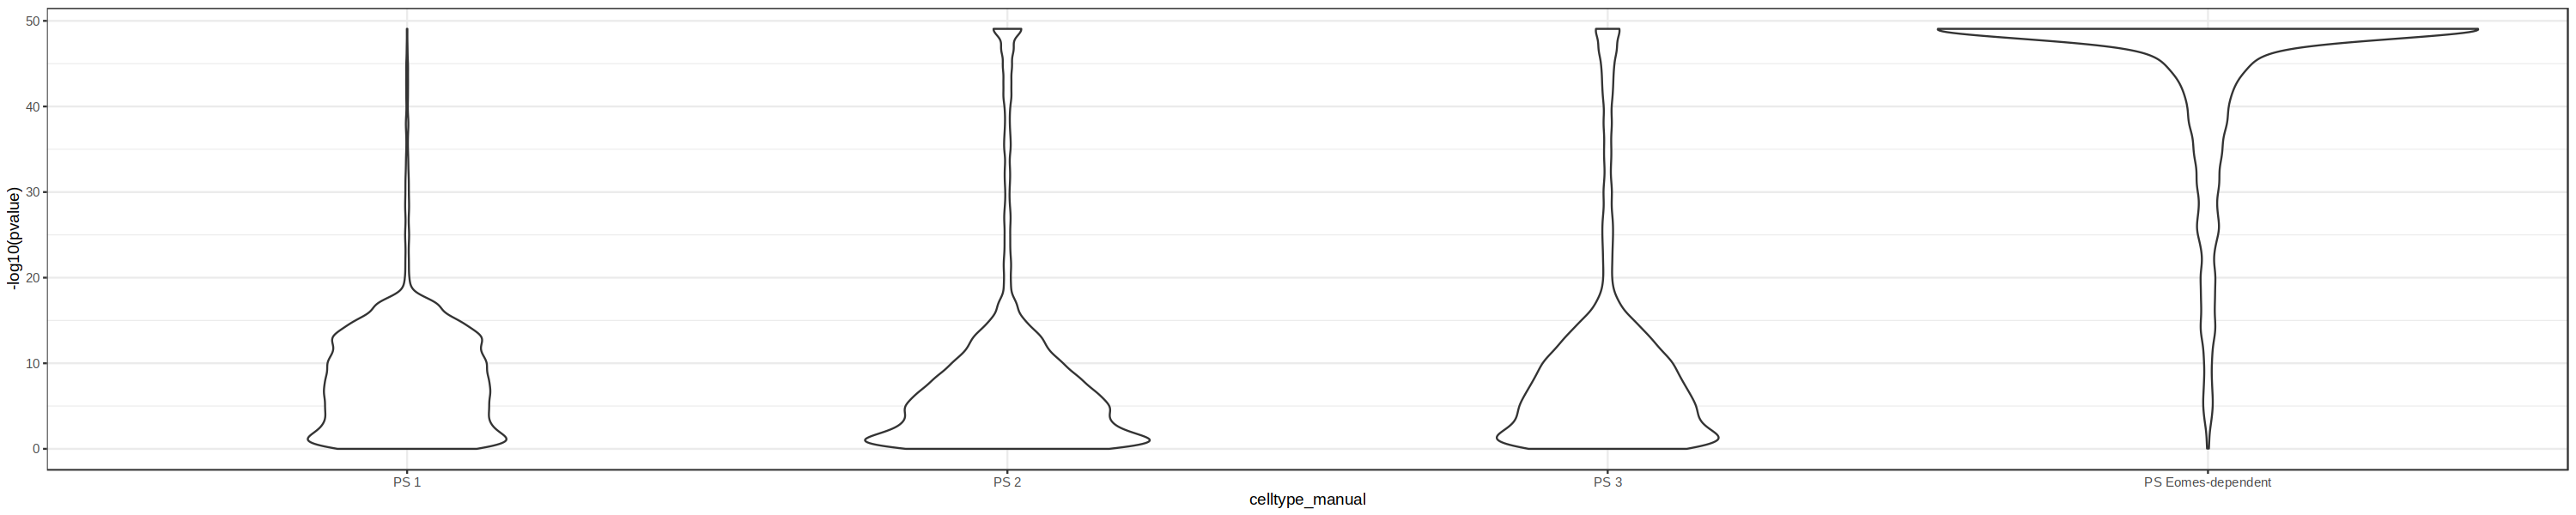

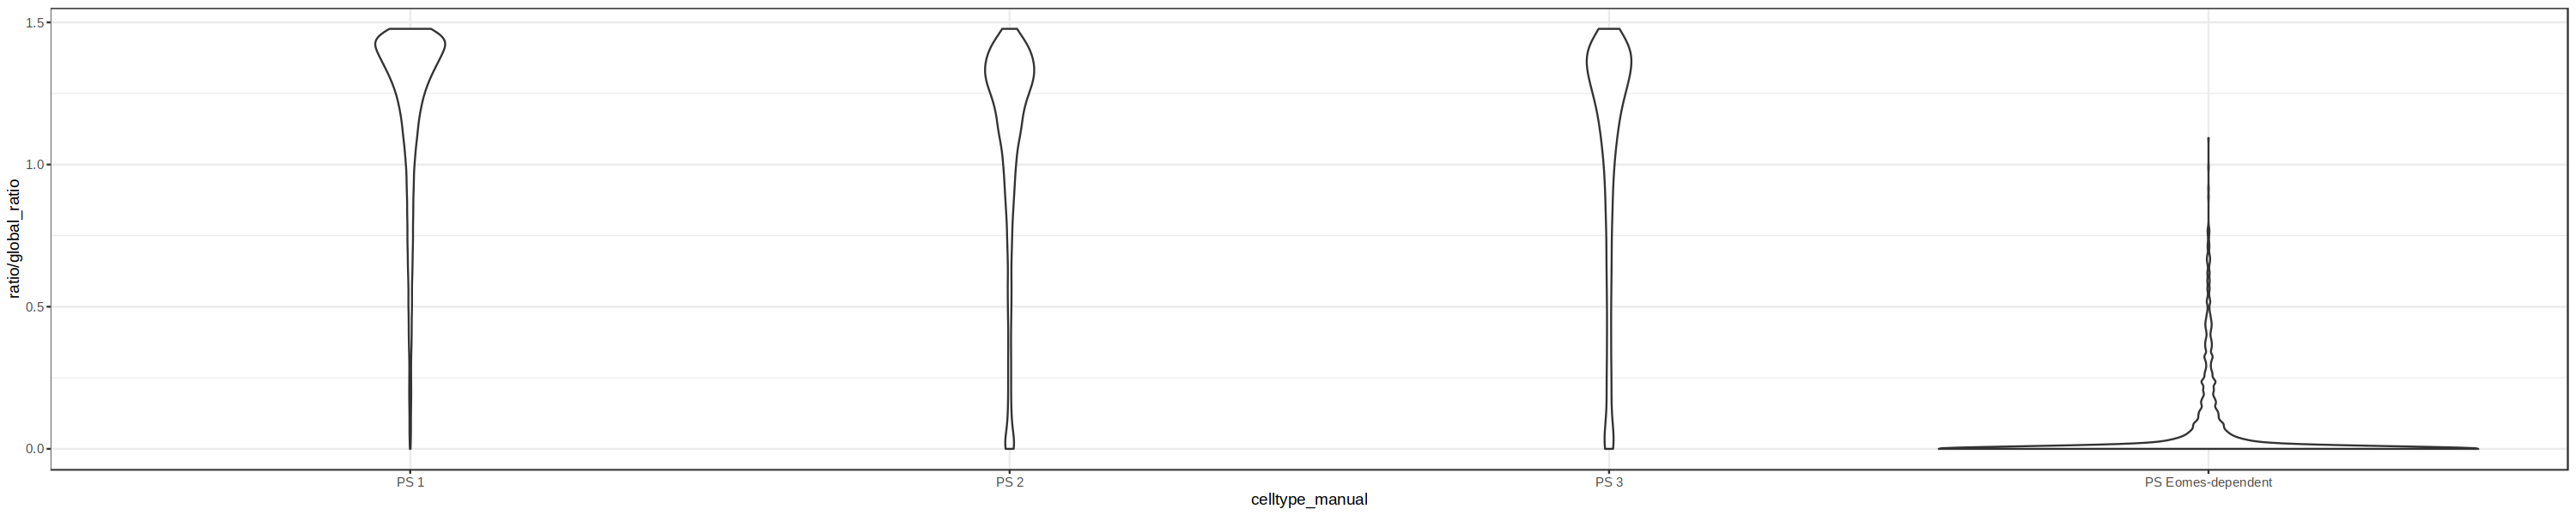

In [43]:
ggplot(meta3, aes(celltype_manual, -log10(pvalue))) + geom_violin() + theme_bw()
ggplot(meta3, aes(celltype_manual, ratio/global_ratio)) + geom_violin() + theme_bw() 

In [44]:
meta3 = meta3[, Eo_depleted := ifelse(pvalue < 1e-20, TRUE, FALSE)]

In [46]:
# Get nearest cells

unique_NN = function(mat, ratio = 1){
    nrcells <- dim(mat)[1]

    # Initialize an empty vector to store unique values
    unique_values <- c()

    # Initialize a logical vector to track processed rows
    processed_rows <- rep(0, nrow(mat))  # Changed to 0 to track the count of unique values per row

    # Loop through each row
    for (row in 1:nrow(mat)) {

      # Go through the columns of the current row
      for (col in 1:ncol(mat)) {

        # Check if we have already taken 2 unique values from this row
        if (processed_rows[row] < ratio) {

          # Get the value from the current cell
          value <- mat[row, col]

          # If the value is not already in the unique_values vector, add it
          if (!value %in% unique_values) {

            unique_values <- c(unique_values, value)
            processed_rows[row] <- processed_rows[row] + 1  # Increment the count of unique values from this row

            # Stop if we have found `2 * nrcells` unique values (since we need 2 per row)
            if (length(unique_values) == ratio * nrcells) {
              break
            }
          }
        }
      }

      # Stop if we already have `ratio * nrcells` unique values
      if (length(unique_values) == ratio * nrcells) {
        break
      }
    }

    # Print the number of rows in the matrix and the length of the unique_values vector
    nrow(mat)
    length(unique_values)
    
    return(unique_values)
    
}

In [47]:
background = factors.mtx[meta3[Eo_depleted != TRUE & 
                            genotype == 'WT',
                      cell],]
query = factors.mtx[meta3[Eo_depleted == TRUE, cell],]

NN = BiocNeighbors::queryKNN(background,
         query = query,
         k = 100)
WT_nearest = rownames(background)[unique_NN(NN$index, ratio = 2)]


In [48]:
background = factors.mtx[meta3[genotype == 'Eomes_KO',
                      cell],]
query = factors.mtx[meta3[Eo_depleted == TRUE, cell],]

NN = BiocNeighbors::queryKNN(background,
         query = query,
         k = 100)

KD_nearest = rownames(background)[unique_NN(NN$index, ratio = 2)]

WT_depleted = meta3[Eo_depleted == TRUE & genotype == 'WT', cell]


In [49]:
head(WT_depleted)

[1] "RBG43475#AAACATGCAGTAAGTA-1" "RBG43475#AAACCAACAGAGAGCC-1"
[3] "RBG43475#AAACCGAAGCTTAACA-1" "RBG43475#AAACCGAAGTTAGACC-1"
[5] "RBG43475#AAACCGCGTAAGGTCC-1" "RBG43475#AAACCGCGTGATGAAA-1"

In [54]:
meta_full = fread(args$metadata)[day != 'D4.5']
meta_full = merge(meta_full, umap, by = 'cell') 

In [64]:
p1 = ggplot(copy(meta)[cell %in% WT_depleted], aes(umap1, umap2)) + 
    ggrastr::rasterize(geom_point(data = meta[!cell %in% WT_depleted], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2, color = 'black'), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    ggtitle('WT Eo-D') + 
    theme_void() + theme(legend.position = 'none')

p2 = ggplot(copy(meta)[cell %in% WT_nearest], aes(umap1, umap2)) + 
    ggrastr::rasterize(geom_point(data = meta[!cell %in% WT_nearest], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2, color = 'blue'), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    ggtitle('WT Eo-I') + 
    theme_void() + theme(legend.position = 'none')

p3 = ggplot(copy(meta)[cell %in% KD_nearest], aes(umap1, umap2)) + 
    ggrastr::rasterize(geom_point(data = meta[!cell %in% KD_nearest], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2, color = 'red'), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    ggtitle('KD Eo-I') + 
    theme_void()  + theme(legend.position = 'none')

# ggarrange(p1, p2, p3, ncol = 3, align = 'h')

In [67]:
ggsave(file.path(args$outdir, 'Early_UMAPs_cellselection.pdf'), 
       plot = ggarrange(p1, p2, p3, ncol = 3, align = 'h'),
       width = 200, 
       height = 60, 
       units = "mm")

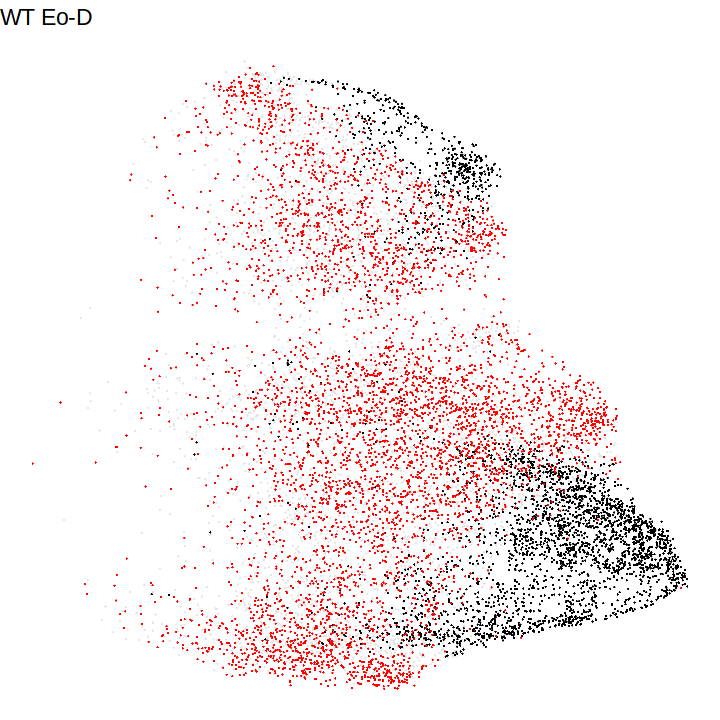

In [63]:
ggplot(copy(meta), aes(umap1, umap2)) + 
    ggrastr::rasterize(geom_point(data = meta[cell %in% WT_nearest], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(data = meta[cell %in% WT_depleted], size = -0.2, color = 'black'), dpi = 600) + 
    ggrastr::rasterize(geom_point(data = meta[cell %in% KD_nearest], size = -0.2, color = 'red'), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    ggtitle('WT Eo-D') + 
    theme_void() + theme(legend.position = 'none')

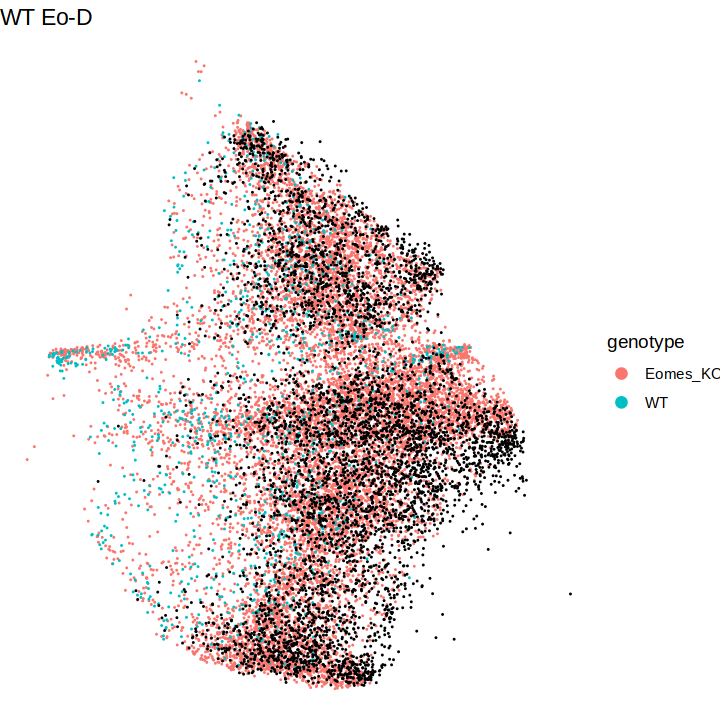

In [72]:
ggplot(copy(meta), aes(umap1, umap2)) + 
    geom_point(data = meta[!cell %in% c(WT_depleted, WT_nearest, KD_nearest)], aes(color = genotype), size = -0.2) +
    geom_point(data = meta[cell %in% c(KD_nearest)], color = 'black', size = -0.2) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    ggtitle('WT Eo-D') + 
    theme_void() 